In [6]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

%load_ext autoreload
%autoreload 2

import os
os.chdir(os.path.expanduser("~/repos/capstone_imperial_ml_ai/src"))

from ml.data import DataLoader, TransformUtils
# from ml.plot import PlotUtils
import numpy as np

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
function = "function_8"
X, y = DataLoader.load_all_function_data(function_name=function)

Loaded data from /workspaces/capstone_imperial_ml_ai/data/initial_data/function_8
Input shape: (40, 8), Output shape: (40,)
Loaded submission data from /workspaces/capstone_imperial_ml_ai/data/submissions/function_8.json
Submission input shape: (1, 8), output shape: (1,)


In [15]:
n=TransformUtils.random_sequence(2, 0.8, 0.99)
print('-'.join(f"{elem:.6f}" for elem in n))


0.870775-0.949874


(np.int64(14),
 array([0.05644741, 0.06595555, 0.02292868, 0.03878647, 0.40393544,
        0.80105533, 0.48830701, 0.89308498]),
 np.float64(9.598482002566342))

(array([14, 26, 40]),
 array([9.598482  , 9.34427428, 9.18489132]),
 array([[0.05644741, 0.06595555, 0.02292868, 0.03878647, 0.40393544,
         0.80105533, 0.48830701, 0.89308498],
        [0.19263987, 0.63067728, 0.41679584, 0.49052929, 0.79608602,
         0.65456706, 0.27624119, 0.29551759],
        [0.284221  , 0.961817  , 0.195416  , 0.116768  , 0.960638  ,
         0.383897  , 0.079476  , 0.166287  ]]))

(array([0.60499445, 0.17800696, 0.00907698, 0.50602816, 0.35990926,
        0.77881834, 0.90864932, 0.58637144, 0.76113733, 0.9849332 ,
        0.11207131, 0.79188751, 0.1435503 , 0.76991655, 0.05644741,
        0.86243745, 0.3515119 , 0.73590364, 0.68029397, 0.04432925,
        0.77834548, 0.89888711, 0.14512029, 0.33895442, 0.17615002,
        0.02894663, 0.19263987, 0.94318502, 0.5327214 , 0.44709584,
        0.38222497, 0.53281953, 0.39486519, 0.98594539, 0.96457339,
        0.47207071, 0.85600695, 0.81003174, 0.79625252, 0.48124533,
        0.284221  ]),
 array([7.3987211 , 7.00522736, 8.45948162, 8.28400781, 8.60611679,
        8.54174792, 7.32743458, 7.29987205, 7.95787474, 5.59219339,
        7.85454099, 6.79198578, 8.97655402, 7.3790829 , 9.598482  ,
        8.15998319, 7.13162397, 6.76796253, 7.43374407, 9.01307515,
        7.31089382, 5.84106731, 9.14163949, 8.81755844, 6.45194313,
        8.83074505, 9.34427428, 6.88784639, 8.04221254, 7.69236805,
        7.92375877, 8.4217

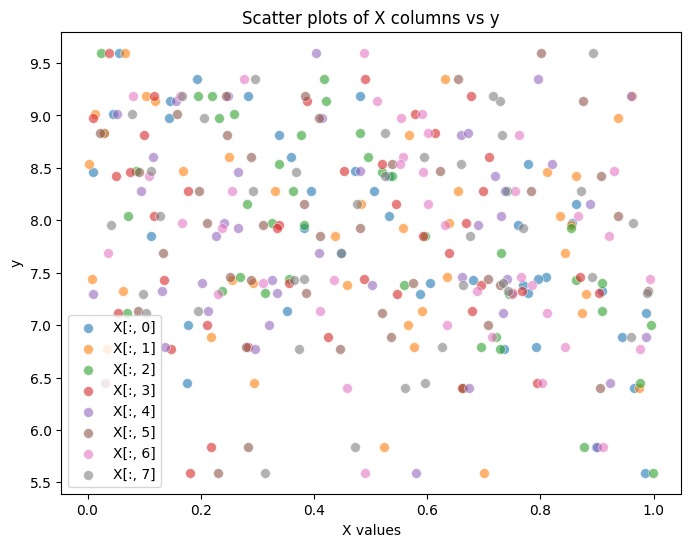

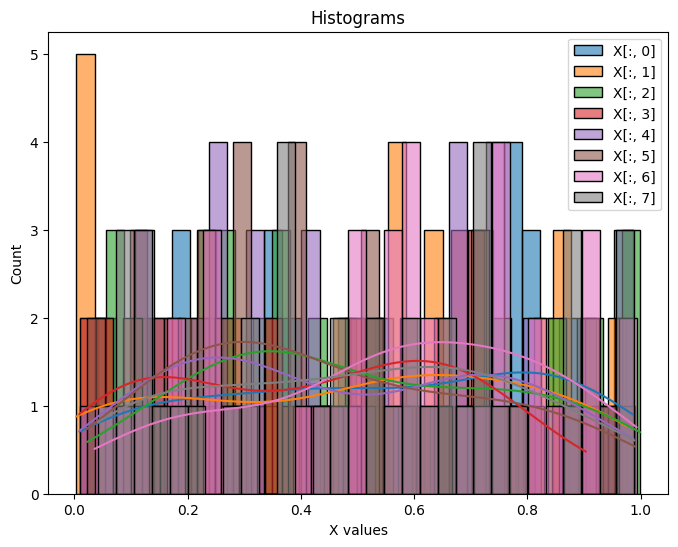

In [13]:
# X
y=np.abs(y)
np.argmax(y), X[np.argmax(y)], np.max(y)
top3_indices = np.argsort(y)[-3:][::-1]
top3_values = y[top3_indices]
top3_X = X[top3_indices]
top3_indices, top3_values, top3_X
X[:, 0], y
PlotUtils.scatter(X=X, y=y)
PlotUtils.histogram(data=X)

In [39]:
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.pipeline import make_pipeline

def scale(X: np.ndarray, y: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    
    x_scaler = StandardScaler(with_mean=True, with_std=True)
    y_scaler = RobustScaler()

    x_log = X #np.log(np.abs(X))
    y_log = np.log(np.abs(y)).reshape(-1, 1) # np.log(np.abs(y)).reshape(-1, 1)
    X_transformed = x_scaler.fit_transform(x_log)
    y_transformed = y_scaler.fit_transform(y_log).ravel()
    
    return X_transformed, y_transformed


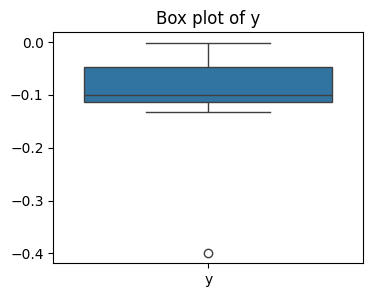

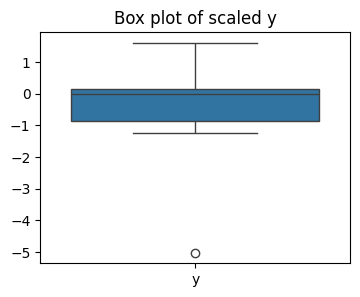

In [40]:
PlotUtils.box(y, figsize=(4, 3), title='Box plot of y')
X_transformed, y_transformed = scale(X, y)
PlotUtils.box(y_transformed, figsize=(4, 3), title='Box plot of scaled y')